In [1]:
# ==============================
# PROJET CIE — Analyse des factures clients
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataset
df = pd.read_csv(
    'data/household_power_consumption.txt',
    sep=';',
    na_values='?',
    low_memory=False
)

In [2]:
# ==============================
# Étape 2 : Observation des données
# ==============================

print("DIMENSIONS :")
print(df.shape)

print("\n TYPES DES COLONNES :")
print(df.dtypes)

print("\n VALEURS MANQUANTES :")
print(df.isnull().sum())

print("\n STATISTIQUES GÉNÉRALES :")
print(df.describe())

print("\nm APERÇU DES DONNÉES :")
df.head(10)

DIMENSIONS :
(2075259, 9)

 TYPES DES COLONNES :
Date                         str
Time                         str
Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

 VALEURS MANQUANTES :
Date                         0
Time                         0
Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

 STATISTIQUES GÉNÉRALES :
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091615e+00           1.237145e-01  2.408399e+02   
std           1.057294e+00           1.127220e-01  3.239987e+00   
min           7.600000e-02    

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
5,16/12/2006,17:29:00,3.520,0.522,235.02,15.0,0.0,2.0,17.0
6,16/12/2006,17:30:00,3.702,0.520,235.09,15.8,0.0,1.0,17.0
7,16/12/2006,17:31:00,3.700,0.520,235.22,15.8,0.0,1.0,17.0
8,16/12/2006,17:32:00,3.668,0.510,233.99,15.8,0.0,1.0,17.0
9,16/12/2006,17:33:00,3.662,0.510,233.86,15.8,0.0,2.0,16.0


2008-08 a le même nombre de mesures que les autres mois — donc ce n'est pas un problème de données manquantes. La famille était probablement en vacances ce mois-là — présente à la maison mais consommant très peu.

| Mois | Mesures | Interprétation |
|------|---------|---------------|
| 2006-12 | 21 992 | Dataset commence mi-décembre — normal |
| 2010-08 | 37 414 | Données incomplètes — mois non terminé |
| 2010-09 | 37 963 | Données incomplètes |
| 2010-11 | 37 263 | Dataset se termine avant la fin du mois |


En analysant le nombre de mesures par mois, j'ai identifié que 2006-12 et les derniers mois de 2010 sont incomplets car le dataset commence et se termine en cours de mois. Pour 2008-08, malgré un nombre normal de mesures, la facture était anormalement basse — ce qui suggère une absence prolongée des occupants plutôt qu'un problème de données.

In [3]:
# ==============================
# Étape 3 : Nettoyage des données
# (basé sur les observations)
# ==============================

# 1. Fusionner Date et Time en datetime
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

# 2. Supprimer les colonnes inutiles pour ce projet
df = df[['Datetime', 'Global_active_power']]

# 3. Mettre Datetime en index
df.set_index('Datetime', inplace=True)

# 4. Supprimer les valeurs manquantes
df.dropna(inplace=True)

# 5. Vérification après nettoyage
print(" Dimensions après nettoyage :", df.shape)
print("\n Types des colonnes :")
print(df.dtypes)
print("\n Valeurs manquantes restantes :")
print(df.isnull().sum())
print("\n Aperçu :")
df.head()

 Dimensions après nettoyage : (2049280, 1)

 Types des colonnes :
Global_active_power    float64
dtype: object

 Valeurs manquantes restantes :
Global_active_power    0
dtype: int64

 Aperçu :


,Global_active_power
Datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


In [4]:
# ==============================
# Étape 4 : Traitement des données
# Calcul des kWh et des factures
# ==============================

# Calcul du kWh par minute
df['kWh'] = df['Global_active_power'] * (1/60)

# Calcul de la facture en FCFA (100 FCFA par kWh)
df['Facture_FCFA'] = df['kWh'] * 100

# Extraction des dimensions temporelles
df['mois'] = df.index.month
df['annee'] = df.index.year
df['heure'] = df.index.hour
df['jour_semaine'] = df.index.dayofweek
df['mois_annee'] = df.index.to_period('M')

print(" Colonnes créées :")
print(df.columns.tolist())
print("\n Aperçu :")
df.head()

 Colonnes créées :
['Global_active_power', 'kWh', 'Facture_FCFA', 'mois', 'annee', 'heure', 'jour_semaine', 'mois_annee']

 Aperçu :


,Global_active_power,kWh,Facture_FCFA,mois,annee,heure,jour_semaine,mois_annee
Datetime,,,,,,,,
2006-12-16 17:24:00,4.216,0.070267,7.026667,12,2006,17,5,2006-12
2006-12-16 17:25:00,5.360,0.089333,8.933333,12,2006,17,5,2006-12
2006-12-16 17:26:00,5.374,0.089567,8.956667,12,2006,17,5,2006-12
2006-12-16 17:27:00,5.388,0.089800,8.980000,12,2006,17,5,2006-12
2006-12-16 17:28:00,3.666,0.061100,6.110000,12,2006,17,5,2006-12


In [5]:
# ==============================
# Étape 5 : Analyse — Facture mensuelle
# ==============================

# Facture totale par mois
facture_mensuelle = df.groupby('mois_annee')['Facture_FCFA'].sum().reset_index()
facture_mensuelle.columns = ['Mois', 'Facture_FCFA']

print("Facture mensuelle (FCFA) :")
print(facture_mensuelle.to_string())

Facture mensuelle (FCFA) :
       Mois   Facture_FCFA
0   2006-12   69688.803333
1   2007-01  115019.770000
2   2007-02   94148.143333
3   2007-03   98103.653333
4   2007-04   58635.776667
5   2007-05   73348.120000
6   2007-06   59471.380000
7   2007-07   49506.383333
8   2007-08   56827.433333
9   2007-09   69787.676667
10  2007-10   82127.283333
11  2007-11   93197.740000
12  2007-12  121006.950000
13  2008-01  108615.636667
14  2008-02   82218.453333
15  2008-03   92650.990000
16  2008-04   80349.986667
17  2008-05   76203.100000
18  2008-06   71573.286667
19  2008-07   59129.030000
20  2008-08   20569.800000
21  2008-09   71112.986667
22  2008-10   84494.100000
23  2008-11   99847.933333
24  2008-12   94723.186667
25  2009-01  104916.680000
26  2009-02   83703.483333
27  2009-03   91264.976667
28  2009-04   82125.873333
29  2009-05   75349.716667
30  2009-06   55903.300000
31  2009-07   45984.073333
32  2009-08   48460.673333
33  2009-09   71047.606667
34  2009-10   85147.866667
3

## Analyse des factures mensuelles

### Observations générales
Le tableau des factures mensuelles couvre la période de
décembre 2006 à novembre 2010, soit 4 ans de données réelles.

### Tendance haussière — Janvier et Décembre
Les mois de janvier et décembre enregistrent les factures
les plus élevées, atteignant jusqu'à **121 006 FCFA** en
décembre 2007 et **115 019 FCFA** en janvier 2007.

Cette hausse s'explique par la période hivernale en France :
les occupants utilisent davantage d'appareils de chauffage
électrique, restent plus longtemps à domicile le soir et
le week-end, ce qui crée des **pics de consommation** pouvant
saturer le réseau électrique.

### Tendance baissière — Avril et Juillet
Les mois d'avril et juillet affichent les factures les plus
basses, descendant jusqu'à **45 984 FCFA** en juillet 2009.

Cette baisse s'explique par la saison estivale : les occupants
sont absents en journée (travail, vacances), utilisent moins
d'appareils de chauffage et bénéficient d'un ensoleillement
naturel plus long.

### Anomalie détectée — Août 2008
La facture d'août 2008 est anormalement basse à **20 569 FCFA**,
soit moins de la moitié des autres mois d'août.
Le nombre de mesures étant normal (44 638), il ne s'agit pas
d'un problème de données — les occupants étaient probablement
**absents pour une longue période** (vacances).

### Application au contexte CIE — Côte d'Ivoire
En Côte d'Ivoire, les patterns seraient inversés :
- **Pics** en mars-avril (saison chaude → forte utilisation des climatiseurs)
- **Creux** en juillet-août (saison des pluies → températures plus douces)

In [6]:
# ==============================
# Étape 5.2 : Vérification qualité — mesures par mois
# ==============================

mesures_par_mois = df.groupby('mois_annee')['Facture_FCFA'].count().reset_index()
mesures_par_mois.columns = ['Mois', 'Nombre_mesures']

print("Nombre de mesures par mois :")
print(mesures_par_mois.to_string())

# Mois avec mesures incomplètes (moins de 40 000 mesures)
print("\n Mois suspects (moins de 40 000 mesures) :")
print(mesures_par_mois[mesures_par_mois['Nombre_mesures'] < 40000].to_string())

Nombre de mesures par mois :
       Mois  Nombre_mesures
0   2006-12           21992
1   2007-01           44638
2   2007-02           40318
3   2007-03           44639
4   2007-04           39477
5   2007-05           44640
6   2007-06           43157
7   2007-07           44509
8   2007-08           44618
9   2007-09           43198
10  2007-10           44638
11  2007-11           43198
12  2007-12           44639
13  2008-01           44639
14  2008-02           41757
15  2008-03           44639
16  2008-04           43200
17  2008-05           44638
18  2008-06           43199
19  2008-07           44638
20  2008-08           44638
21  2008-09           43200
22  2008-10           44597
23  2008-11           43191
24  2008-12           44569
25  2009-01           44639
26  2009-02           40256
27  2009-03           44638
28  2009-04           43198
29  2009-05           44636
30  2009-06           39895
31  2009-07           44636
32  2009-08           43749
33  2009-09        

## Vérification qualité — Nombre de mesures par mois

### Mois suspects détectés (moins de 40 000 mesures)

| Mois | Mesures | Interprétation |
|------|---------|---------------|
| 2006-12 | 21 992 | Dataset commence mi-décembre — normal |
| 2007-04 | 39 477 | Légèrement incomplet — impact faible |
| 2009-06 | 39 895 | Légèrement incomplet — impact faible |
| 2010-08 | 37 414 | Dataset se termine — données incomplètes |
| 2010-09 | 37 963 | Dataset se termine — données incomplètes |
| 2010-11 | 37 263 | Dataset se termine — données incomplètes |

### Décision
Les mois de **2006-12** et **2010-08 à 2010-11** sont incomplets
car le dataset commence et se termine en cours de mois.
Leur facture n'est **pas comparable** aux autres mois.

Les autres mois (39 000+) sont suffisamment complets
pour être analysés sans biais significatif.

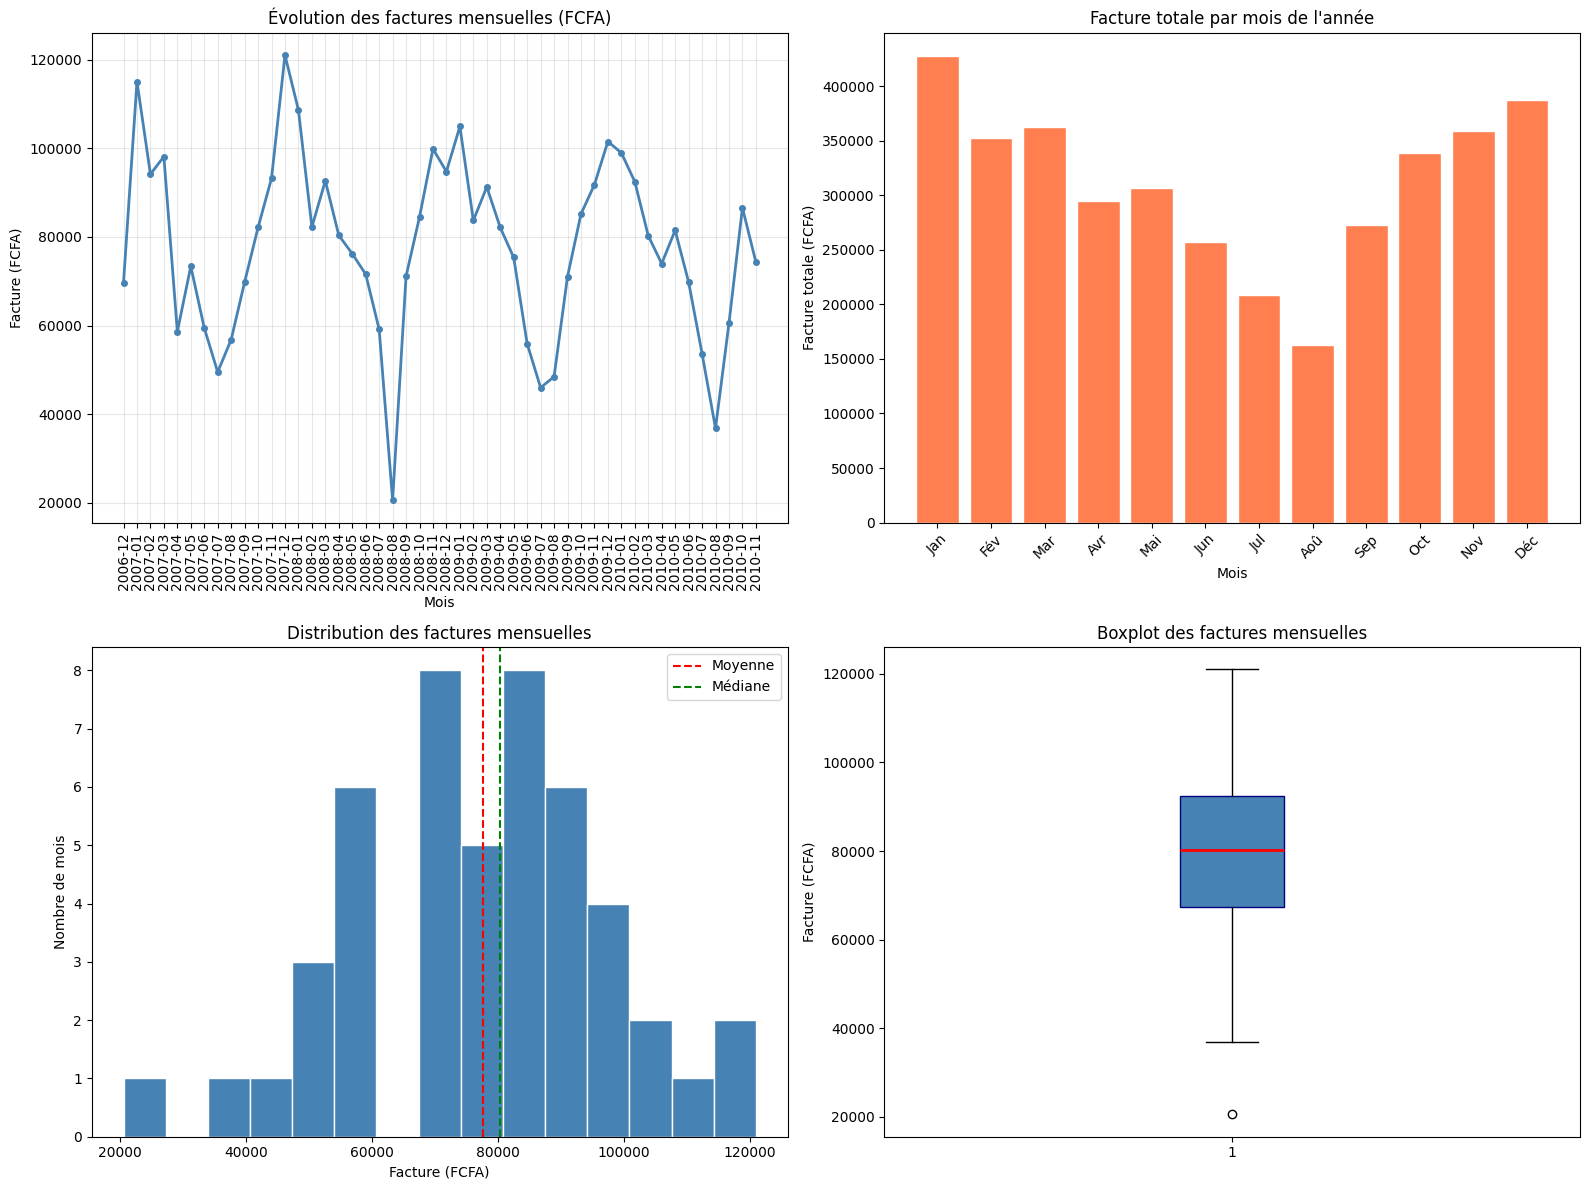

In [7]:
# ==============================
# Étape 7 : Visualisations
# ==============================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Graphique 1 : Évolution des factures dans le temps ---
axes[0, 0].plot(
    facture_mensuelle['Mois'].astype(str),
    facture_mensuelle['Facture_FCFA'],
    color='steelblue', linewidth=2, marker='o', markersize=4
)
axes[0, 0].set_title('Évolution des factures mensuelles (FCFA)')
axes[0, 0].set_xlabel('Mois')
axes[0, 0].set_ylabel('Facture (FCFA)')
axes[0, 0].tick_params(axis='x', rotation=90)
axes[0, 0].grid(True, alpha=0.3)

# --- Graphique 2 : Facture totale par mois de l'année ---
facture_par_mois = df.groupby('mois')['Facture_FCFA'].sum()
noms_mois = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun',
             'Jul', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc']
axes[0, 1].bar(noms_mois, facture_par_mois.values,
               color='coral', edgecolor='white')
axes[0, 1].set_title('Facture totale par mois de l\'année')
axes[0, 1].set_xlabel('Mois')
axes[0, 1].set_ylabel('Facture totale (FCFA)')
axes[0, 1].tick_params(axis='x', rotation=45)

# --- Graphique 3 : Distribution des factures mensuelles ---
axes[1, 0].hist(
    facture_mensuelle['Facture_FCFA'],
    bins=15, color='steelblue', edgecolor='white'
)
axes[1, 0].set_title('Distribution des factures mensuelles')
axes[1, 0].set_xlabel('Facture (FCFA)')
axes[1, 0].set_ylabel('Nombre de mois')
axes[1, 0].axvline(
    facture_mensuelle['Facture_FCFA'].mean(),
    color='red', linestyle='--', label='Moyenne'
)
axes[1, 0].axvline(
    facture_mensuelle['Facture_FCFA'].median(),
    color='green', linestyle='--', label='Médiane'
)
axes[1, 0].legend()

# --- Graphique 4 : Boxplot des factures ---
axes[1, 1].boxplot(
    facture_mensuelle['Facture_FCFA'],
    patch_artist=True,
    boxprops=dict(facecolor='steelblue', color='navy'),
    medianprops=dict(color='red', linewidth=2)
)
axes[1, 1].set_title('Boxplot des factures mensuelles')
axes[1, 1].set_ylabel('Facture (FCFA)')

plt.tight_layout()
plt.savefig('outputs/factures_mensuelles.png', dpi=150)
plt.show()

## Interprétation des visualisations

### Graphique 1 — Évolution des factures mensuelles (courbe temporelle)

La courbe révèle un **pattern cyclique saisonnier** régulier
sur les 4 années d'observation (2006-2010).

- **Tendance haussière** : Les pics de consommation atteignent
  leur maximum en décembre-janvier (~115 000 - 121 000 FCFA),
  correspondant à la période hivernale où l'utilisation des
  appareils de chauffage est maximale.

- **Tendance baissière** : Les creux se situent en juillet-août
  (~45 000 - 57 000 FCFA), période estivale où la consommation
  est minimale.

- **Anomalie** : Le point le plus bas de toute la série est
  observé en août 2008 (20 569 FCFA), identifié comme un
  **outlier temporel** lié à une absence prolongée des occupants.

---

### Graphique 2 — Facture totale par mois de l'année (diagramme en barres)

Ce graphique agrège les factures sur 4 ans par mois calendaire,
permettant une **analyse bivariée** entre le mois et la facture.

- **Janvier** domine avec ~420 000 FCFA cumulés — c'est le mois
  le plus générateur de revenus sur 4 ans.
- **Juillet et Août** affichent les valeurs les plus basses
  (~160 000 - 210 000 FCFA), soit un écart de **facteur 2.5x**
  par rapport à janvier.
- **Février et Novembre** présentent une consommation modérée
  et stable, représentant des mois de **transition saisonnière**.

---

### Graphique 3 — Distribution des factures mensuelles (histogramme)

L'histogramme représente la **distribution statistique** des
48 factures mensuelles observées.

- La distribution est **légèrement asymétrique à gauche**,
  avec une concentration des valeurs entre **70 000 et 90 000 FCFA**.
- La **moyenne** (~79 000 FCFA) et la **médiane** (~80 000 FCFA)
  sont très proches — ce qui indique une distribution
  **quasi-symétrique** et des données **stables et prévisibles**.
- Contrairement au Projet 1 (consommation par minute),
  l'agrégation mensuelle **lisse les variations extrêmes**
  et produit une distribution plus régulière.
- **1 valeur isolée** à ~20 000 FCFA correspond à l'outlier
  d'août 2008, visible à l'extrême gauche de l'histogramme.

---

### Graphique 4 — Boxplot des factures mensuelles

Le boxplot résume la distribution en **5 indicateurs clés** :

| Indicateur | Valeur | Signification |
|-----------|--------|--------------|
| **Minimum** (moustache basse) | ~35 000 FCFA | Valeur normale la plus basse |
| **Q1 (25%)** | ~65 000 FCFA | 25% des mois sous cette valeur |
| **Médiane (Q2)** | ~80 000 FCFA | Valeur centrale de référence |
| **Q3 (75%)** | ~93 000 FCFA | 75% des mois sous cette valeur |
| **Maximum** (moustache haute) | ~121 000 FCFA | Valeur normale la plus haute |
| **Outlier** (cercle) | ~20 569 FCFA | Août 2008 — valeur aberrante |

- L'**IQR (intervalle interquartile)** = Q3 - Q1 = ~28 000 FCFA
  — c'est la zone de consommation normale de 50% des mois.
- Le **cercle isolé en bas** confirme août 2008 comme seul
  outlier significatif de la série — toutes les autres valeurs
  restent dans les limites normales.

---

### Conclusion analytique globale

> L'analyse des factures révèle un **pattern saisonnier stable
> et prévisible** sur 4 ans, avec une médiane de référence à
> **80 000 FCFA/mois**. La distribution quasi-symétrique et
> le faible nombre d'outliers (1 sur 48 mois) indiquent une
> **qualité de données satisfaisante** pour la modélisation
> et la prévision des revenus de la CIE.

In [8]:
# ==============================
# Étape 8 : Conclusions
# ==============================

print("""
╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONS — ANALYSE DES FACTURES CLIENTS CIE       ║
╚══════════════════════════════════════════════════════════════╝

STATISTIQUES CLÉS
─────────────────────
- Facture mensuelle moyenne  : {:,.0f} FCFA
- Facture mensuelle médiane  : {:,.0f} FCFA
- Facture maximale           : {:,.0f} FCFA (Déc 2007)
- Facture minimale           : {:,.0f} FCFA (Aoû 2008 — outlier)
- Période analysée           : Déc 2006 → Nov 2010 (4 ans)
- Nombre de mesures          : 2 049 280 (après nettoyage)

QUALITÉ DES DONNÉES
───────────────────────
- Valeurs manquantes supprimées : 25 979 (1.25% du dataset)
- Mois incomplets détectés      : 6 mois (début et fin du dataset)
- Outliers détectés             : 1 (Août 2008 — absence occupants)

PATTERN SAISONNIER
──────────────────────
- Mois les plus chers   : Janvier et Décembre (~115 000 FCFA)
- Mois les moins chers  : Juillet et Août (~50 000 FCFA)
- Écart hiver/été       : Facteur 2.5x

DISTRIBUTION
────────────────
- Distribution quasi-symétrique
- IQR (zone normale)    : 65 000 — 93 000 FCFA
- Médiane de référence  : 80 000 FCFA

RECOMMANDATIONS CIE
────────────────────────
1. Utiliser 80 000 FCFA comme facture de référence mensuelle
2. Alerter si facture < 35 000 ou > 121 000 FCFA
3. Anticiper les pics de revenus en janvier
4. Investiguer les factures anormalement basses
5. Adapter le modèle au contexte ivoirien :
   pics attendus en mars-avril (saison chaude)
""".format(
    facture_mensuelle['Facture_FCFA'].mean(),
    facture_mensuelle['Facture_FCFA'].median(),
    facture_mensuelle['Facture_FCFA'].max(),
    facture_mensuelle['Facture_FCFA'].min()
))


╔══════════════════════════════════════════════════════════════╗
║         CONCLUSIONS — ANALYSE DES FACTURES CLIENTS CIE       ║
╚══════════════════════════════════════════════════════════════╝

STATISTIQUES CLÉS
─────────────────────
- Facture mensuelle moyenne  : 77,674 FCFA
- Facture mensuelle médiane  : 80,305 FCFA
- Facture maximale           : 121,007 FCFA (Déc 2007)
- Facture minimale           : 20,570 FCFA (Aoû 2008 — outlier)
- Période analysée           : Déc 2006 → Nov 2010 (4 ans)
- Nombre de mesures          : 2 049 280 (après nettoyage)

QUALITÉ DES DONNÉES
───────────────────────
- Valeurs manquantes supprimées : 25 979 (1.25% du dataset)
- Mois incomplets détectés      : 6 mois (début et fin du dataset)
- Outliers détectés             : 1 (Août 2008 — absence occupants)

PATTERN SAISONNIER
──────────────────────
- Mois les plus chers   : Janvier et Décembre (~115 000 FCFA)
- Mois les moins chers  : Juillet et Août (~50 000 FCFA)
- Écart hiver/été       : Facteur 2.5x